# Quick Start: In silico Tissue Perturbation  


- **Creator**: Amir Akbarnejad (aa36@sanger.ac.uk)
- **Affiliation**: Wellcome Sanger Institute and University of Cambridge
- **Date of Creation**: 02.07.2025
- **Date of Last Modificaion**: 17.07.2025 (sebastian.birk@helmholtz-munich.de)

This tutorial demonstrates in silico tissue perturbations via MintFlow.
**To be able to run the notebook, the parts that you need to modify are specified by `TODO:MODIFY:`. The rest can be left untouched, as far as the goal is to run the notebook.**  

This notebook is only for demonstration, and to get biologically meaningful results you may need different settings.

In [1]:
import os, sys
import yaml
import mintflow
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm
import numpy as np
from pprint import pprint

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

import mintflow
import mintflow.interface.perturbation.module_gen_micsizefactor
import mintflow.interface.perturbation.module_gen_stdata

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/team361/sb75/mintflow/src/mintflow/utils_pyg.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## 1. Overview
Before reading this tutorial, please make sure you have read the other tutorial notebook titled "Quick Start: Generate Expression Data for a Customized Tissue".  

In this tutorial we are going to generate expression data for two tissues
- **Original tissue**: A crop of our original tissue
- **Modified tissue**: The same tissue crop, but with some of its cell types altered 

Afterwards, we perform differential analysis between the generated expression data for the two aforementioned tissues to identify genes that are up/down regulated as a result of cell type labels being altered. 

In the following we demonstrate the steps of doing this.

## 2. Download a sample AnnData object and a sample MintFlow checkpoint
 
- Download this sample `.h5ad` file from Google Drive: [(link to the file on Google Drive)](https://drive.google.com/file/d/187Y44hpY5OuwMu0_PA9r9WvycMOx-uz5/view?usp=sharing)
and place it in a directory of your choice. Thereafter, set the variable `path_anndata` below to the path where you placed the `.h5ad` file.
- In the first tutorial notebook we demonstrated how to save a checkpoint on disk by calling `mintflow.dump_checkpoint`. Download this sample checkpoint file from google drive [(link to the file on Doogle Grive)](https://drive.google.com/file/d/1KS40-BCE4Zapq0osNjRkMEXs8IGRQj3g/view?usp=sharing)
and place it in a directory of your choice. Thereafter, set the variable `path_checkpoint` below to the path where you placed the `.pt` file.



In [2]:
path_anndata = './NonGit/data_train_single_section.h5ad'  
# TODO:MODIFY: set to the path where you've put the `.h5ad` file that you downloaded above.

path_checkpoint = './NonGit/sample_checkpoint.pt'  
# TODO:MODIFY: set to the path where you've put the `.pt` file that you downloaded above.

## 3. Load the MintFlow checkpoint

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [4]:
checkpoint_mintflow = torch.load(
    path_checkpoint,
    map_location='cpu',
    weights_only=False
)
checkpoint_mintflow['model'].to(device)
print("Loaded the checkpoint.")

Loaded the checkpoint.


## 4. Make the original tissue 
Here we create a crop of the tissue section (i.e. we create the "Original tissue" we explained above in the overview section) and store it in `adata_original`.

In [5]:
adata = sc.read_h5ad(
    path_anndata
)
adata_original = adata[
    (adata.obs['x_centroid'] > 5000.0) &  (adata.obs['x_centroid'] < 6000.0) &\
    (adata.obs['y_centroid'] > 2100.0) &  (adata.obs['y_centroid'] < 2500.0)
].copy()

/tmp/ipykernel_486825/1312595077.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


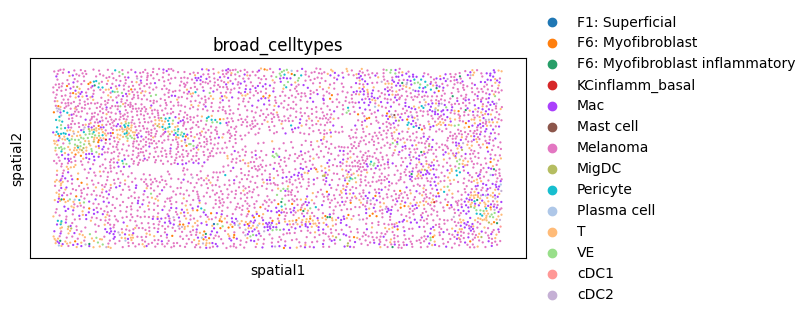

In [6]:
sc.pl.spatial(
    adata_original,
    spot_size=5,
    color='broad_celltypes'
)

## 5. Make a modified (i.e. perturbed) version of the tissue
Here we perturb the tissue by altering some of its cell type labels and obtain the "Modified tissue" described above in the overview section.
Note that this perturbation is for demonstraion only rather than getting biologically meaningful results.

In [7]:
adata_perturbed = adata_original.copy()
adata_perturbed.obs['broad_celltypes'] = adata_perturbed.obs['broad_celltypes'].replace(
    {'cDC2':'MigDC'}
) 

/tmp/ipykernel_486825/3110252419.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_perturbed.obs['broad_celltypes'] = adata_perturbed.obs['broad_celltypes'].replace(


/tmp/ipykernel_486825/3135614259.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


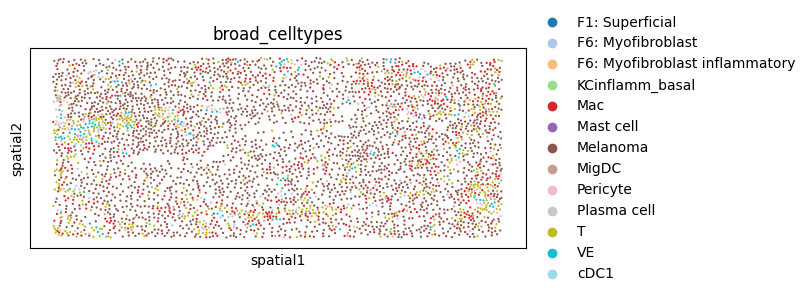

In [8]:
sc.pl.spatial(
    adata_perturbed,
    color='broad_celltypes',
    spot_size=5,
    palette='tab20'
)

In [9]:
# create the neighborhood graph
kwargs_neighbourhood_graph = {
    'spatial_key': 'spatial',
    'library_key': None,
    'set_diag': False,
    'delaunay': False,
    'n_neighs': 5
}
adata.uns = {}
sq.gr.spatial_neighbors(
    adata=adata,
    **kwargs_neighbourhood_graph
)

## 6. Create neighborhood graphs for both tissues
We recommend creating a new neighborhood graph for the original/perturbed version of tissue, instead of using the original graph. It's crucial if the perturbed version of tissue has a different number of cells due to, e.g., some cell types being dropped (instead of being altered) in the perturbed tissue.  

In [10]:
kwargs_neighbourhood_graph = {
    'spatial_key': 'spatial',
    'library_key': None,
    'set_diag': False,
    'delaunay': False,
    'n_neighs': 10
}
adata_original.uns = {}
adata_perturbed.uns = {}

sq.gr.spatial_neighbors(
    adata=adata_original,
    **kwargs_neighbourhood_graph
)
sq.gr.spatial_neighbors(
    adata=adata_perturbed,
    **kwargs_neighbourhood_graph
)

## 7. Generate expression data for each tissue
Now in the following we generate expression data for `adata_original` and `adata_perturbed`.

Some important arguments to pass to the function `mintflow.generate_insilico_ST_data`:
- `obskey_celltype`: the column name of the `.obs` field that contains cell type labels. Cell type labels have to be among the ones seen during training.
- `batch_index_trainingdata`: generation is conditioned on batch index as well. For example if `batch_index_trainingdata` is set to 1, generation is conditioned on batch with index 1 seen during training. Note that this index is zero-based. To check the batch index assigned to each tissue section, you can run the below cell.
- `estimate_spatial_sizefactors_on_sections`: To generate `Xint` and `Xmic` two size factors are needed. To generate these size factors, MintFlow filters out cells with similar cell type labels and MCC vectors in some tissue sections. This argument specifies the tissue section(s) used for this purpose.

In [11]:
# prints the batch index assigned to each tissue section in the training set
pprint(checkpoint_mintflow['data_mintflow']['train_list_tissue_section'].map_Batchname_to_inflowBatchID)

{'Melanoma': 'inflow_BatchID_0'}


In [12]:
result_generation_original = mintflow.generate_insilico_ST_data(
    adata=adata_original,
    obskey_celltype='broad_celltypes',
    obspkey_neighbourhood_graph='spatial_connectivities',
    device=device,
    batch_index_trainingdata=0,
    num_generated_realisations=5,
    model=checkpoint_mintflow['model'],
    data_mintflow=checkpoint_mintflow['data_mintflow'],
    dict_all4_configs=checkpoint_mintflow['dict_all4_configs'],
    estimate_spatial_sizefactors_on_sections=[0]
)

Evaluating on tissue section: 0:   0%|          | 0/1655 [00:00<?, ?it/s]

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


Generating the realisations of the expression data (i.e. generative samples) for the provided in silico tissue…

/nfs/team361/sb75/mintflow/src/mintflow/generativemodel.py:546: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(edge_index),
/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


In [13]:
result_generation_perturbed = mintflow.generate_insilico_ST_data(
    adata=adata_perturbed,
    obskey_celltype='broad_celltypes',
    obspkey_neighbourhood_graph='spatial_connectivities',
    device=device,
    batch_index_trainingdata=0,
    num_generated_realisations=5,
    model=checkpoint_mintflow['model'],
    data_mintflow=checkpoint_mintflow['data_mintflow'],
    dict_all4_configs=checkpoint_mintflow['dict_all4_configs'],
    estimate_spatial_sizefactors_on_sections=[0]
)

Evaluating on tissue section: 0:   0%|          | 0/1655 [00:00<?, ?it/s]

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


Generating the realisations of the expression data (i.e. generative samples) for the provided in silico tissue…

/nfs/team361/sb75/mintflow/src/mintflow/generativemodel.py:546: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(edge_index),
/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


## 8. Put the generated expression data in `.obsm` field of AnnData objects
The generative model can generate more than one expression data or "realization" for each tissue, and the variation in the expression of each gene among the generated samples or "realizations" can be informative. But to keep it simple here, in the following we put the average expression over different realizations in the `.obsm` field of AnnData objects. For pooling strategies other than averaging, you can alter `.mean(0)` in the following two cells.

In [14]:
adata_original.obsm['MintFLow_Generated_Xmic'] = np.stack(
    [realisation['MintFLow_Generated_Xmic'] for realisation in result_generation_original['list_generated_realisations_ie_expressions']]
).mean(0)

In [15]:
adata_perturbed.obsm['MintFLow_Generated_Xmic'] = np.stack(
    [realisation['MintFLow_Generated_Xmic'] for realisation in result_generation_perturbed['list_generated_realisations_ie_expressions']]
).mean(0)

## 9. Identify cells whose microenvironment cell type composition (MCC) is changed
Differential expression analysis should be performed only on cells whose micro-environment (i.e. their MCC, Micro-environment Cell type Composition) is different in the original/perturbed versions of tissue. Therefore here we identify those cells. 
Here we make use of `.obs['cell_id']` column of the AnnData object to find each cell in original and perturbed tissues. If your AnnData object doesn't have a `.obs['cell_id']` field, you can add it initially yourself.   

Find the index of each cell ID in `adata_original` and `adata_perturbed`

In [16]:
list_cellID_original = adata_original.obs['cell_id'].tolist()
list_cellID_perturbed = adata_perturbed.obs['cell_id'].tolist()

dict_cellID_to_indexOriginal = {
    cell_id: list_cellID_original.index(cell_id)
    for cell_id in set(adata_original.obs['cell_id']).union(set(adata_perturbed.obs['cell_id']))
}
dict_cellID_to_indexPerturbed = {
    cell_id: list_cellID_perturbed.index(cell_id)
    for cell_id in set(adata_original.obs['cell_id']).union(set(adata_perturbed.obs['cell_id']))
}

The value returned by `mintflow.generate_insilico_ST_data` contains the MCC (Micro-environment Cell type Composition) vectors. Here we make use of them to see if the MCC of each cell is altered between original and perturbed versions of tissue. 

In [17]:
dict_cellID_to_MCChaschanged = {}
for cell_id in set(adata_original.obs['cell_id'].tolist()).union(set(adata_perturbed.obs['cell_id'].tolist())):
    if (cell_id not in adata_original.obs['cell_id'].tolist()) or (cell_id not in adata_perturbed.obs['cell_id'].tolist()):
         # if the cell is dropped or added during perturbation --> No differential expression on it
        dict_cellID_to_MCChaschanged[cell_id] = False
    else:
        dict_cellID_to_MCChaschanged[cell_id] = np.allclose(
            result_generation_original['np_MCC'][dict_cellID_to_indexOriginal[cell_id]],
            result_generation_perturbed['np_MCC'][dict_cellID_to_indexPerturbed[cell_id]]
        )
        

In [18]:
print("For {} percent of cells, the MCC has changed due to perturbation.".format(
    np.round(
        100.0 * np.mean([v for u, v in dict_cellID_to_MCChaschanged.items()]),
        3
    )
))

For 87.245 percent of cells, the MCC has changed due to perturbation.


## 10. Perform differential expression analysis
We perform the analysis separately for each cell type, and only among cells whose MCC is changed.

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


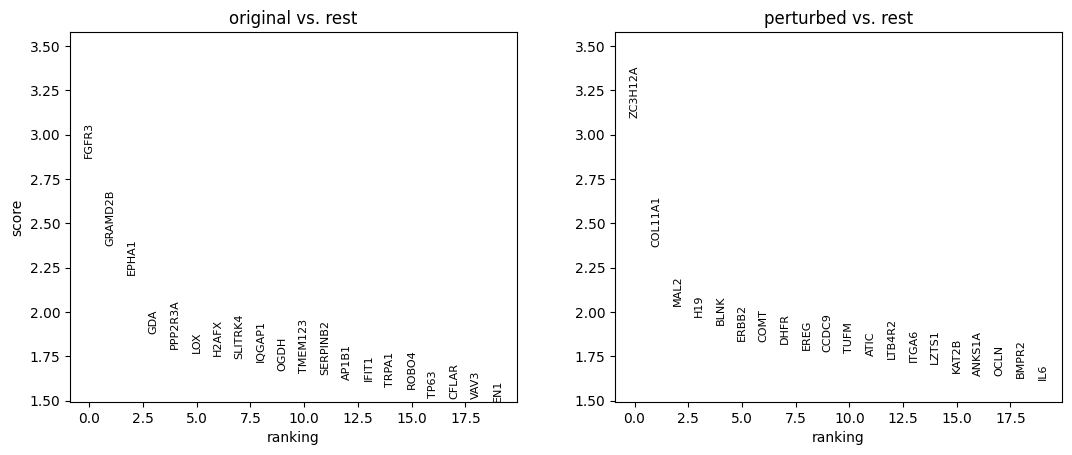

Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


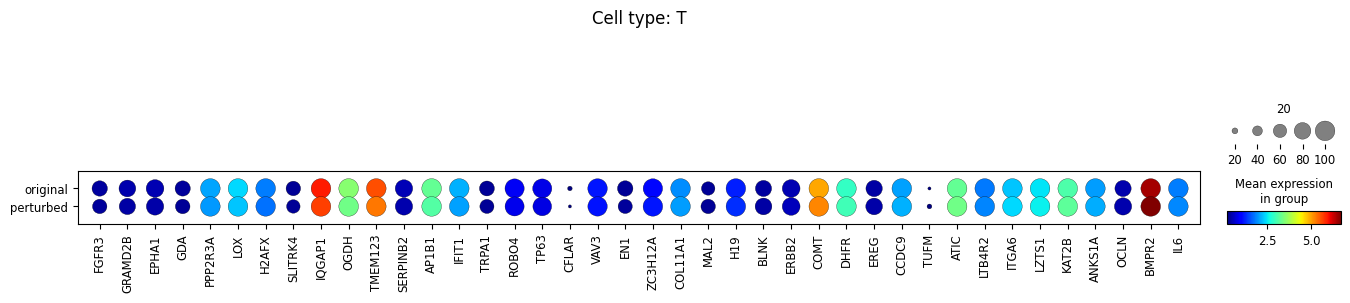

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


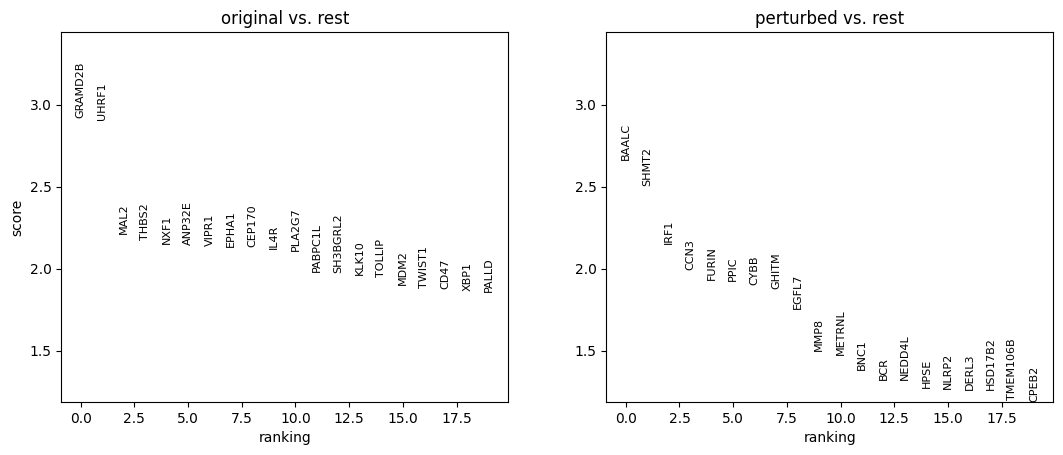

Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


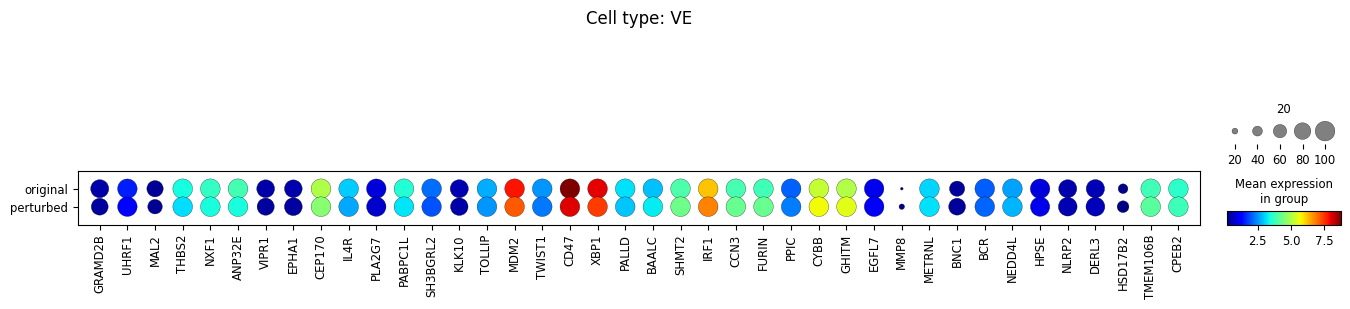

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


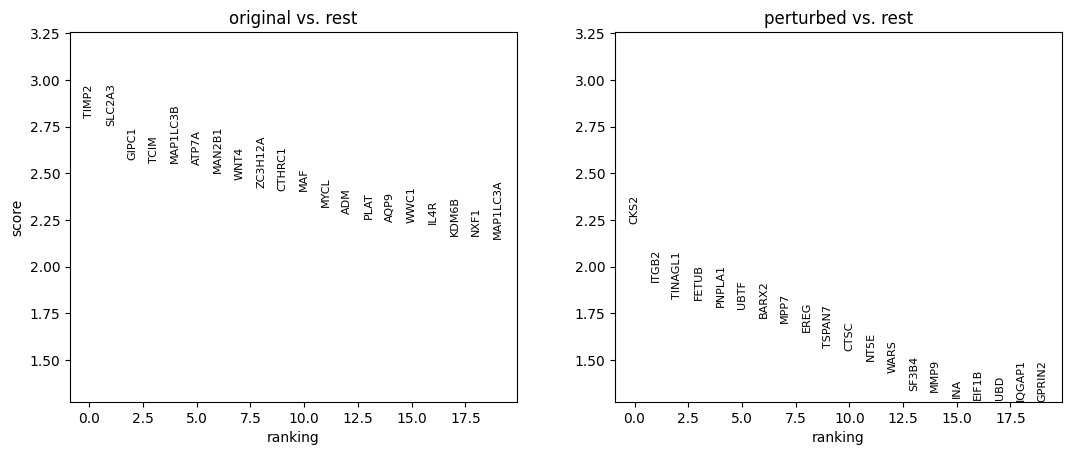

Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


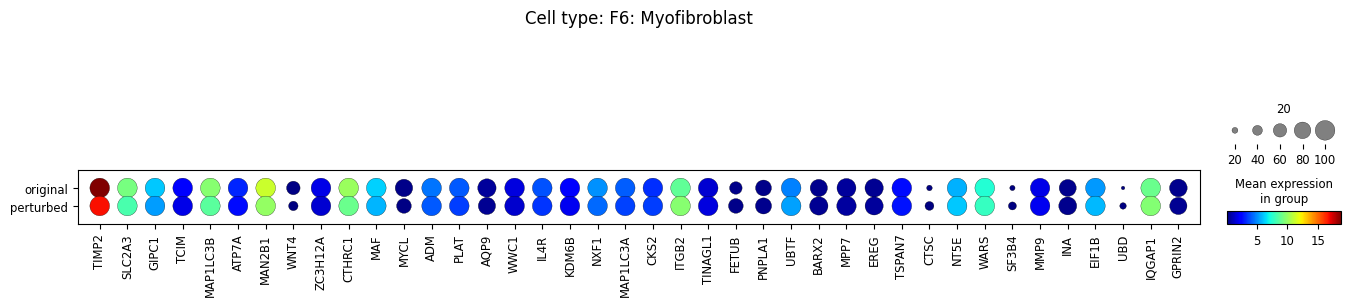

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


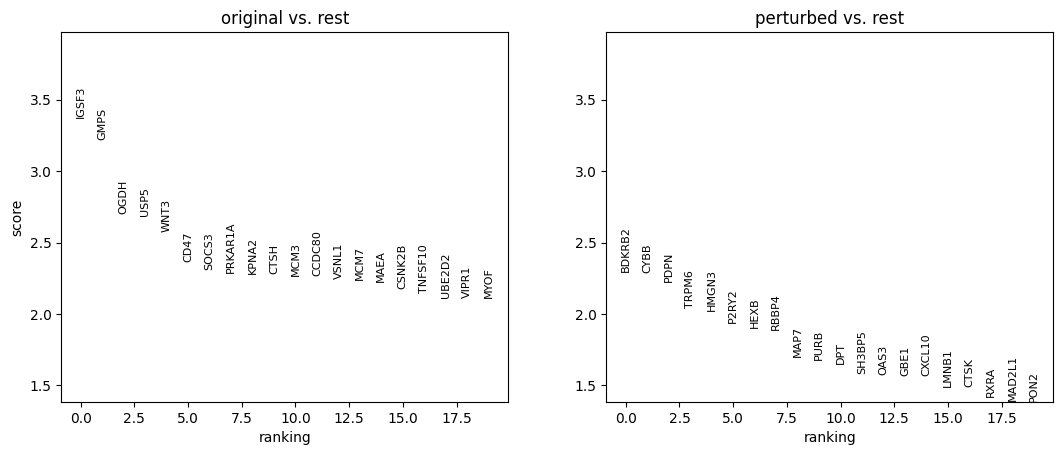

Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


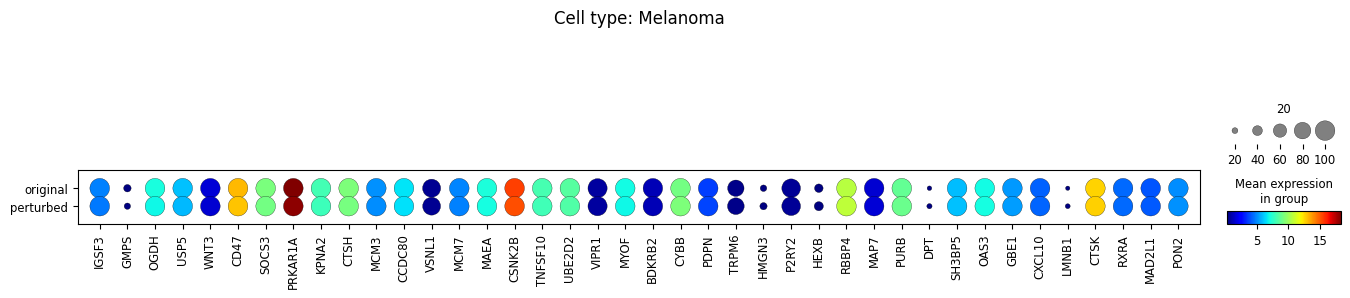

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


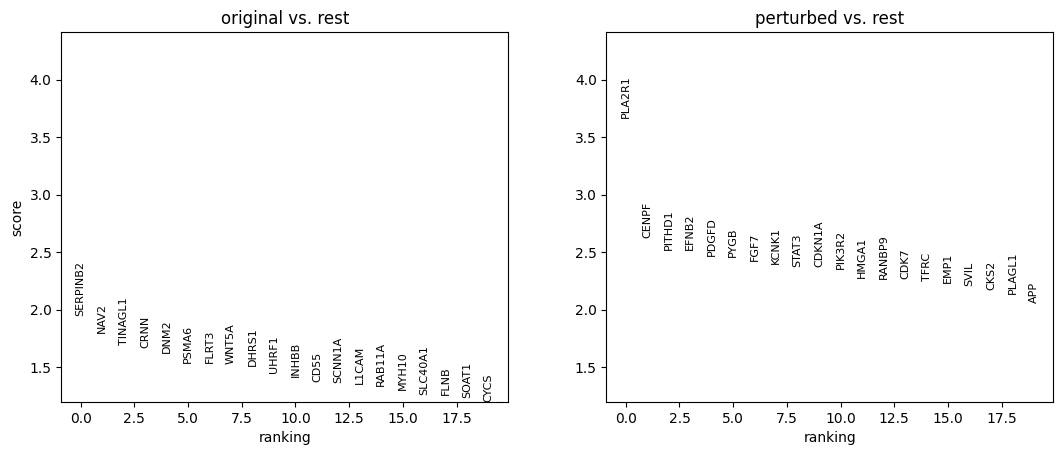

Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


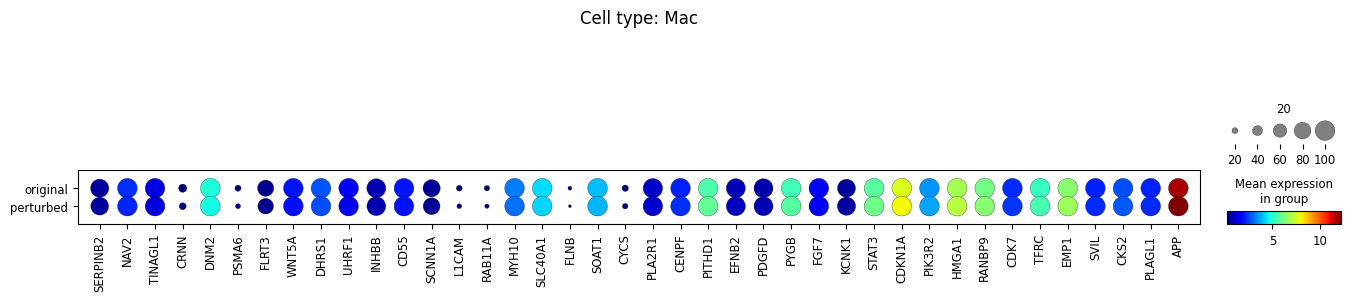

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


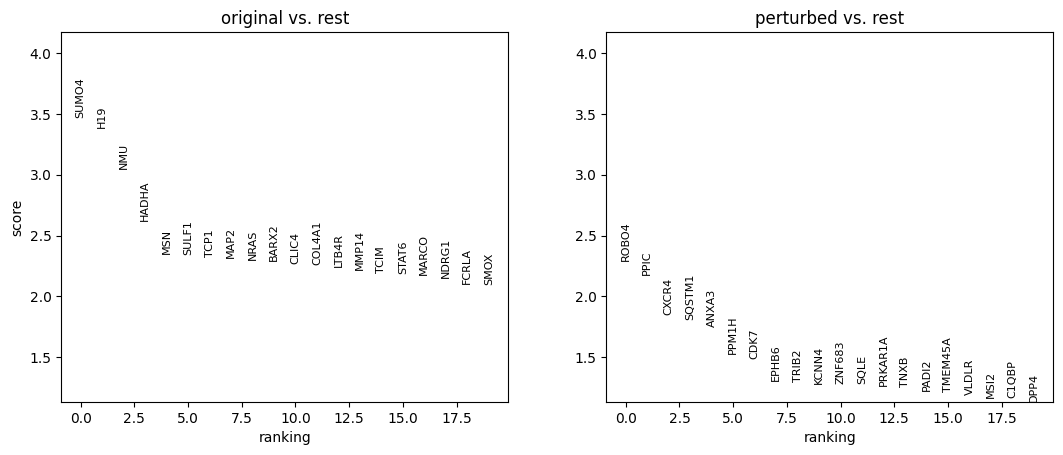

Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


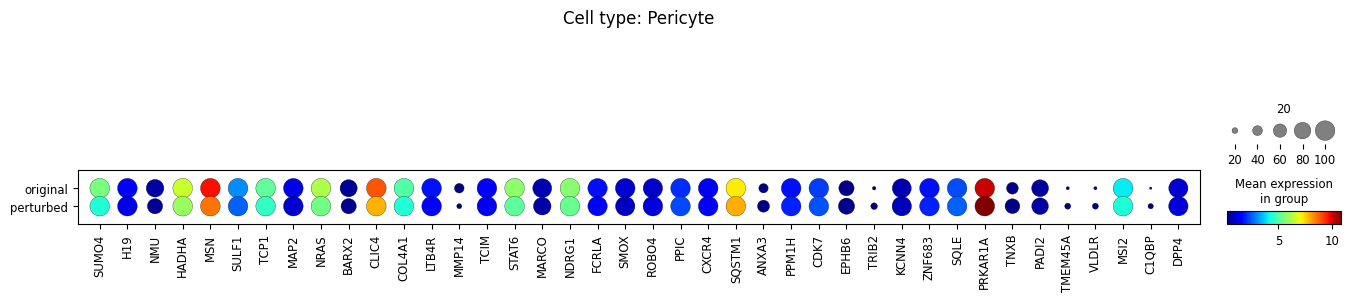

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


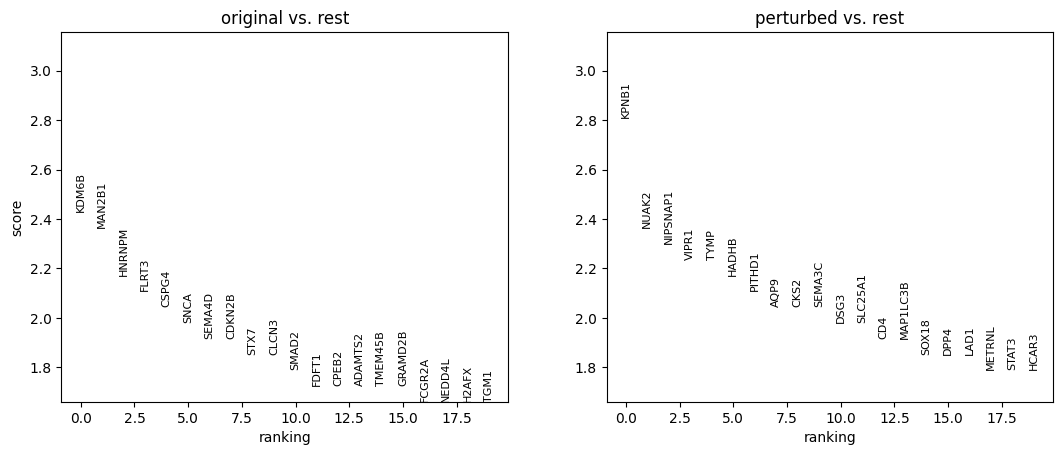

Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


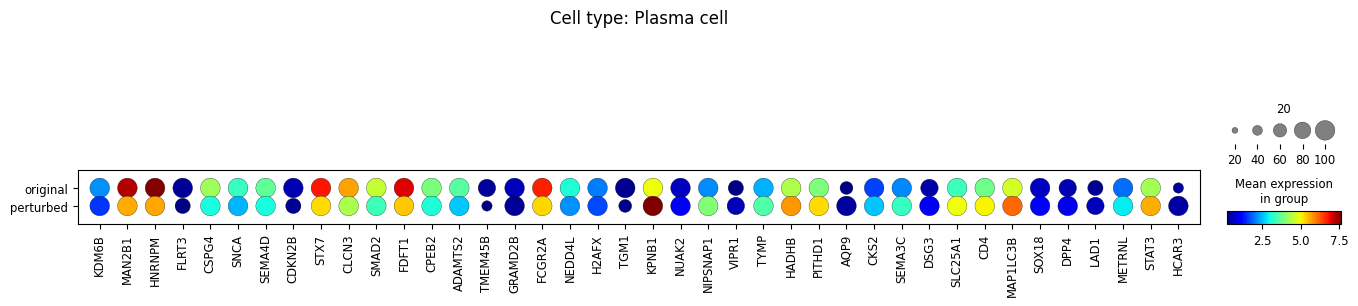

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


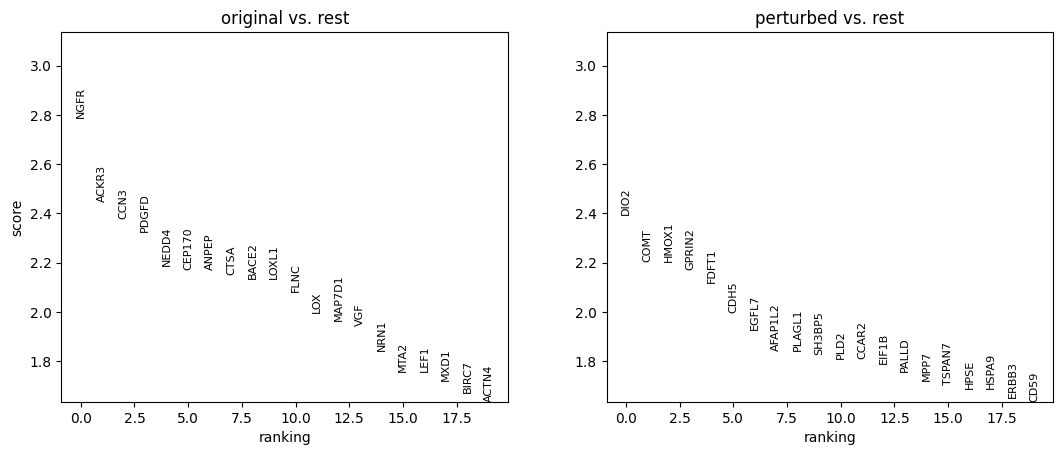

Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


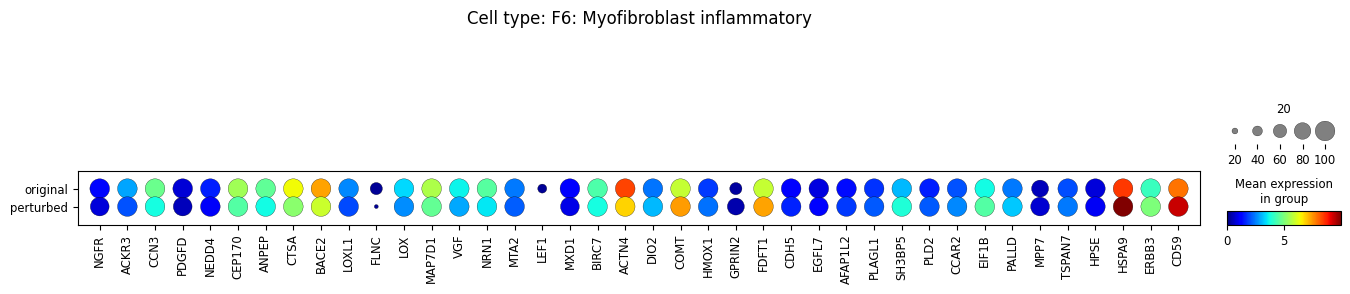

/nfs/users/nfs_s/sb75/.venvs/mintflow/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


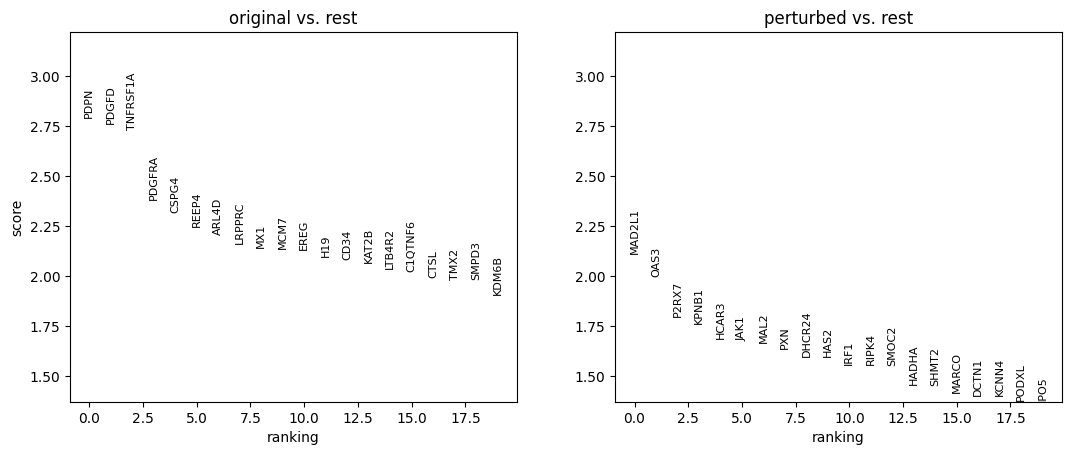

Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


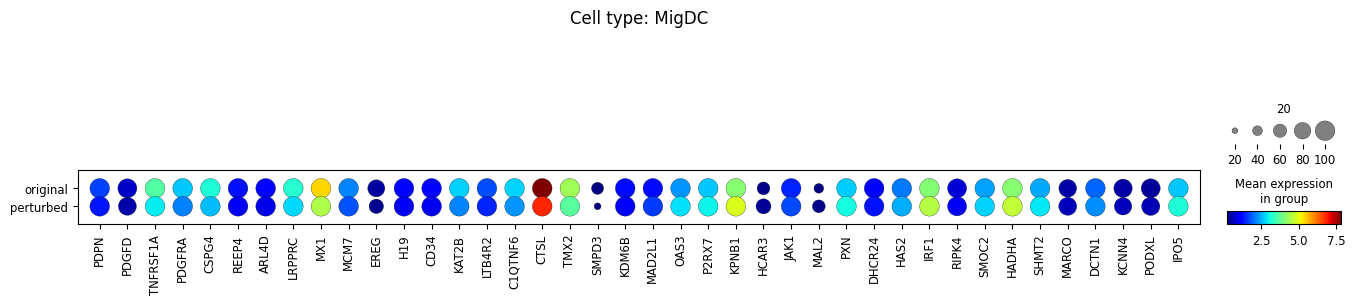

In [19]:
for ct in set(adata_perturbed.obs['broad_celltypes']):
    row_filter_original = np.logical_and(
        np.array(adata_original.obs['broad_celltypes']  == ct),  # filter based on cell type
        np.array([
            dict_cellID_to_MCChaschanged[cell_id]
            for cell_id in adata_original.obs['cell_id'].tolist()
        ])  # filter based on if MCC vector has changed
    )
    row_filter_perturbed = np.logical_and(
        np.array(adata_perturbed.obs['broad_celltypes']  == ct),  # filter based on cell type
        np.array([
            dict_cellID_to_MCChaschanged[cell_id]
            for cell_id in adata_perturbed.obs['cell_id'].tolist()
        ])  # filter based on if MCC vector has changed
    )
    
    

    if np.sum(np.logical_and(row_filter_original, row_filter_perturbed)) <= 2:
        continue  # not enough cells --> skip the DE analysis

    # make an anndata for DE analysis
    adata_DEanalysis = sc.AnnData(
        X=np.concatenate(
            [adata_original.obsm['MintFLow_Generated_Xmic'][row_filter_original.tolist()] + 0.0,
             adata_perturbed.obsm['MintFLow_Generated_Xmic'][row_filter_perturbed.tolist()] + 0.0],
            0
        ),
        obs=pd.DataFrame(
            data=np.array(
                [sum(row_filter_original)*['original'] +\
                 sum(row_filter_perturbed)*['perturbed']]
            ).T,
            columns=['original_vs_perturbed']
        ),
        var=adata_original.var
    )


    # perform the DE analysis
    adata_DEanalysis.layers['xspl_before_log1p'] = adata_DEanalysis.X.copy()
    sc.pp.log1p(adata_DEanalysis)


    sc.tl.rank_genes_groups(
        adata_DEanalysis,
        'original_vs_perturbed',
        method='wilcoxon',
        n_genes=20
    )
    sc.pl.rank_genes_groups(adata_DEanalysis)
    sc.pl.dotplot(
        adata_DEanalysis,
        var_names=\
        [u[0] for u in adata_DEanalysis.uns['rank_genes_groups']['names'].tolist()]+\
        [u[1] for u in adata_DEanalysis.uns['rank_genes_groups']['names'].tolist()],
        groupby='original_vs_perturbed',
        dendrogram=True,
        title="Cell type: {}".format(ct),
        size_title=20,
        cmap='jet',
        layer='xspl_before_log1p',
        mean_only_expressed=True
    )

Note that the above outputs are only meant to demonstrate how to run the perturbation analysis. To reproduce manuscript results please refer to our reproducibility GitHub repository.